# Sentiment Analysis

Necessary imports

In [1]:
import pandas as pd
import numpy as np

# sentiment analysis
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# visualisation
import matplotlib.pyplot as plt 

nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/icedspice/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Loading the cleaned parquet file

In [44]:
# load the cleaned dataset
df = pd.read_parquet("dataset/bitcoin_tweet.parquet")

# structure of dataframe
df.head()

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,mentions,account_age_days,age_bucket,url_count,text_clean
16,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,3-5 yr,0,- 39000$ This is so amazing. I am impressed wi...
24,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,>10 yr,0,Not now as there is fud of sub $30k ...people ...
25,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,[BTC],[],1161,3-5 yr,0,I personally ignore weekend moves and chill wi...
31,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,"[Bitcoin, BTC]",[],1287,3-5 yr,0,Move Digital Energy Through Cyber Space.
51,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...","[cronje, frognation, BTC]",[],1812,3-5 yr,0,"1/2 End of shitcoin season, lasted even longer..."


## VADER Model

In [6]:
sia = SentimentIntensityAnalyzer()

# applies vader sentiment analyzer to cleaned text
# creates new column in dataframe for vader compound score

df["vader_compound"] =  df["text_clean"].astype(str).apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

# function to classify vader compound sentiment scores 

def classify_vader_sentiment(compound) :
    if compound >= 0.05 :
        return "positive"
    elif compound <= -0.05 :
        return "negative"
    else:
        return "neutral"

# creats new column in data frame for vader classification

df["vader_sentiment"] = df["vader_compound"].apply(classify_vader_sentiment)

df.head(5)

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,mentions,account_age_days,age_bucket,url_count,text_clean,vader_compound,vader_sentiment
16,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,['BTC'],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,3-5 yr,0,- 39000$ This is so amazing. I am impressed wi...,0.9396,positive
24,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,['BTC'],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,>10 yr,0,Not now as there is fud of sub $30k ...people ...,-0.6597,negative
25,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,['BTC'],[],1161,3-5 yr,0,I personally ignore weekend moves and chill wi...,-0.3612,negative
31,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,"['Bitcoin', 'BTC']",[],1287,3-5 yr,0,Move Digital Energy Through Cyber Space.,0.2732,positive
51,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...","['cronje', 'frognation', 'BTC']",[],1812,3-5 yr,0,"1/2 End of shitcoin season, lasted even longer...",-0.6705,negative


## RoBERTa Model

## VADER Sentiment Distribution

In [12]:
# Percentage of VADER sentiment according to classification
vader_counts = df["vader_sentiment"].value_counts(normalize=True) * 100

vader_counts

vader_sentiment
positive    48.794408
neutral     28.519138
negative    22.686454
Name: proportion, dtype: float64

## Visualisation

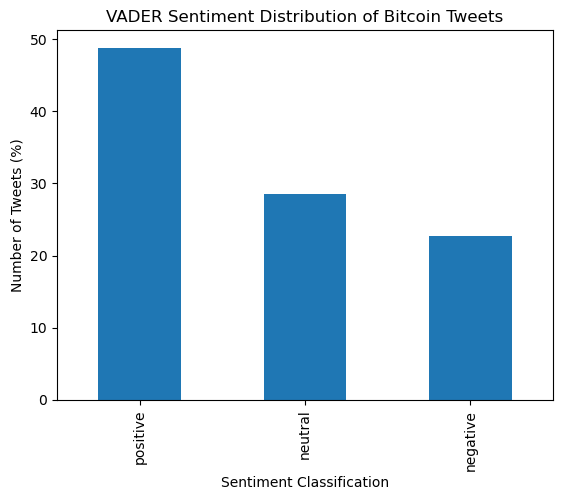

In [17]:
vader_counts.plot(kind="bar")

plt.title("VADER Sentiment Distribution of Bitcoin Tweets")
plt.xlabel("Sentiment Classification")
plt.ylabel("Number of Tweets (%)")
plt.show()

In [27]:
df = df.drop(columns=["month"])

In [28]:
df.head()

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,mentions,account_age_days,age_bucket,url_count,text_clean,vader_compound,vader_sentiment
16,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,['BTC'],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,3-5 yr,0,- 39000$ This is so amazing. I am impressed wi...,0.9396,positive
24,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,['BTC'],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,>10 yr,0,Not now as there is fud of sub $30k ...people ...,-0.6597,negative
25,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,['BTC'],[],1161,3-5 yr,0,I personally ignore weekend moves and chill wi...,-0.3612,negative
31,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,"['Bitcoin', 'BTC']",[],1287,3-5 yr,0,Move Digital Energy Through Cyber Space.,0.2732,positive
51,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...","['cronje', 'frognation', 'BTC']",[],1812,3-5 yr,0,"1/2 End of shitcoin season, lasted even longer...",-0.6705,negative


## VADER Average Monthly Sentiment

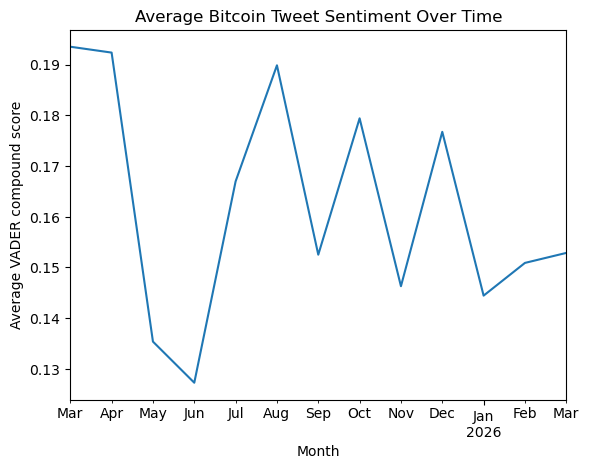

In [35]:
monthly_vader = (
    df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

monthly_vader.plot()

plt.title("Average Bitcoin Tweet Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Average VADER compound score")
plt.show()

## Sentiment by user type

In [57]:
# dataframe of only verified users
verified_df = df[df["user_verified"] == True]

# dataframe of only unverified users
unverified_df = df[df["user_verified"] == False]

print(f'Number of verified users: {len(verified_df)}')

print(f'Number of unverified users: {len(unverified_df)}')

verified_df.head()

# monthly average sentiment for verified users
verified_monthly_vader = (
    verified_df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)
# monthly average sentiment for unverified users
unverified_monthly_vader = (
    unverified_df.set_index("date")
    .resample("ME")["vader_compound"]
    .mean()
)

fig, axes = plt.subplots(1,2, figsize=(14,5))

verified_monthly_vader.plot(ax=axes[0])
axes[0].set_title("Average Bitcoin Tweet Sentiment Over Time\nVerified Users")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average VADER compound score")

unverified_monthly_vader.plot(ax=axes[1])
axes[1].set_title("Average Bitcoin Tweet Sentiment Over Time\nUnverified Users")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average VADER compound score")


Number of verified users: 4773
Number of unverified users: 627406


KeyError: 'Column not found: vader_compound'